# Materi 2: VSM, Normalisasi Teks, TF-IDF, dan Reduksi Dimensi (PCA)

Melanjutkan dari **Materi 1**, pada notebook ini kita melakukan pemrosesan teks (*Text Mining*) terhadap kumpulan berita yang sudah diekstrak ke dalam format CSV.

### Alur Pemrosesan:
1. **Load Data**: Membaca dataset berita `berita.csv` dari folder `Output/`.
2. **Pembersihan & Pembakuan Kata**: Case folding, penghapusan karakter khusus/URL, dan normalisasi kata tidak baku (slang/singkatan) ke bentuk baku.
3. **Ekstraksi Kata Unik & Hitung Kata**: Menghitung total kata dan mengekstrak kata unik (*vocabulary*) menggunakan `sklearn.feature_extraction.text.CountVectorizer`.
4. **Representasi TF-IDF**: Mengubah teks berita ke dalam matriks bobot TF-IDF menggunakan `sklearn.feature_extraction.text.TfidfVectorizer`.
5. **Reduksi Dimensi (PCA)**: Mengurangi ribuan dimensi fitur kata menjadi 2 komponen utama (`PC1` dan `PC2`) menggunakan `sklearn.decomposition.PCA` serta memvisualisasikannya.

## 1. Import Library
Library yang digunakan meliputi `pandas` untuk manipulasi tabel data, `numpy`, `re` untuk regex pembersihan teks, `matplotlib` untuk visualisasi, serta modul `sklearn` untuk pemrosesan teks dan reduksi dimensi.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA


## 2. Memuat Data dari File CSV
Data diambil dari file `Output/berita.csv` yang merupakan hasil scraping 100 berita sport dan 100 berita finance pada Materi 1.

In [2]:
csv_path = "Output/berita.csv" if os.path.exists("Output/berita.csv") else "../output/berita.csv"
df = pd.read_csv(csv_path)

display(df.head(5))
print(f"Total berita yang dimuat: {len(df)} baris")


,ID,Isi Berita,Label
0,1,"Timnas basket putra Indonesia gagal melaju ke perempatfinal Asian Games 2026. Pelatih David Singleton menyebut hasil tersebut sebagai kegagalan dan menegaskan evaluasi menyeluruh akan dilakukan.\nYudha Saputera dkk gagal meraih kemenangan dalam tiga pertandingan Grup A. Indonesia kalah telak dari Jepang 53-98, kemudian takluk 48-102 dari Korea Selatan, dan kembali menelan kekalahan saat menghadapi Arab Saudi dengan skor 89-100.\nHasil tersebut membuat Indonesia finis di posisi keempat Grup A dengan tiga poin dari tiga kekalahan. Tim Merah Putih pun harus mengakhiri kiprahnya lebih awal. Singleton secara terbuka mengakui hasil tersebut tidak sesuai dengan standar yang ditetapkan untuk tim nasional.\n""Kami menilai hasil ini sebagai kegagalan. Kami yakin masih banyak potensi yang bisa kami tunjukkan, namun kami tidak mendapatkan proses adaptasi yang cukup cepat selama berada di Jepang,"" kata pelatih yang karib disapa Dave ini dikutip dari laman federasi.\nSingleton menegaskan timnya tidak ingin mencari alasan atas hasil buruk tersebut. Menurutnya, Indonesia membutuhkan lebih banyak pengalaman bertanding dan waktu kebersamaan, terutama dalam persiapan menghadapi Asian Games.\n""Kami tidak mencari-cari alasan. Itu poin utamanya. Jika harus menjawab berdasarkan fakta, kami sebenarnya membutuhkan lebih banyak pengalaman bertanding dan waktu kebersamaan, terutama bagi tim Asian Games. Kami baru benar-benar bangkit dan menunjukkan kemampuan terbaik kami pada pertandingan ketiga,"" jelasnya.\nMeski gagal meraih kemenangan, Singleton menilai para pemain tetap menunjukkan perjuangan hingga pertandingan terakhir. ""Hal yang ingin saya tekankan adalah tim kami tetap tampil dan berjuang hingga akhir. Kami ingin masyarakat Indonesia tahu bahwa kami tidak akan pernah menyerah,"" ujarnya.\n| Pelatih Timnas basket putra Indonesia David Singleton Foto: Dok. Perbasi | \nNamun, Singleton mengakui penampilan Indonesia belum mencerminkan kemampuan sebenarnya.\n""Sayangnya, kami tidak bisa menunjukkan jati diri kami yang sesungguhnya hingga pertandingan terakhir melawan Arab Saudi. Ini bukanlah standar yang ingin kami tetapkan di level tim nasional,"" tegas Singleton.\nKegagalan di Asian Games 2026 pun menjadi bahan evaluasi besar bagi seluruh elemen tim. Evaluasi tidak hanya menyasar pelatih dan pemain, tetapi juga staf pendukung, aspek organisasi, hingga penjadwalan.\n""Kami harus mengevaluasi segalanya. Federasi memiliki harapan agar kami meraih kemenangan dan tampil lebih baik. Oleh karena itu, mulai dari pelatih, pemain, staf pendukung, hingga aspek organisasi dan penjadwalan, semuanya akan dievaluasi dan diperbaiki,"" tuturnya.\nSingleton juga menilai pembenahan tidak boleh berhenti di level tim senior. Pengembangan pemain dan pelatih dari level akar rumput dinilai penting untuk menyiapkan generasi berikutnya.\n""Kami sebenarnya tidak jauh dari pencapaian hasil yang lebih baik, namun kami harus bergerak dalam hal pengembangan dan peningkatan, tidak hanya di level senior, tetapi juga di tingkat akar rumput (baik bagi pemain maupun pelatih), demi generasi mendatang.""\n""Kami akan mencari berbagai cara untuk melakukan perbaikan, baik pada masa persiapan maupun selama kompetisi berlangsung,"" tegas Singleton.\n(mcy/krs)",sport
1,2,"Perbasi merilis roster Timnas Basket 3x3 Putri Indonesia yang akan berlaga di Asian Games 2026. Empat pemain dipilih untuk membawa Merah Putih dalam ajang yang digelar di Jepang tersebut.\nKeempat pemain itu adalah Jesslyne Jaya Wiyanto, Thasya Hery Saputera, Erlina Christiana, dan Diva Intan Nur Fadillah. Mereka akan berjuang di bawah asuhan Deny Sartika.\nDeny optimistis dengan komposisi yang dimiliki Timnas Basket 3x3 Putri Indonesia. Ia menilai skuadnya memiliki perpaduan pemain big dan small yang dapat menjadi modal menghadapi persaingan di fase grup.\n""Komposisi ini secara size ada dua pemain big dan dua small. Nana dan Thasya dengan pengalamannya bisa mengangkat tim dan nge-lead teman-

Total berita yang dimuat: 199 baris


## 3. Pembersihan Teks dan Pembakuan Kata

Pada tahap ini kita melakukan:
1. **Case Folding**: Mengubah semua huruf menjadi huruf kecil (*lowercase*).
2. **Pembersihan Karakter**: Menghapus URL, angka, dan tanda baca.
3. **Pembakuan Kata (Normalisasi Slang/Singkatan)**: Mengganti kata tidak baku/singkatan (misal: `tdk` $\rightarrow$ `tidak`, `yg` $\rightarrow$ `yang`, `dgn` $\rightarrow$ `dengan`) menjadi kata baku bahasa Indonesia.

In [3]:
# Kamus normalisasi kata tidak baku -> baku
kamus_baku = {
    'tdk': 'tidak', 'tak': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'enggak': 'tidak',
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'dlm': 'dalam', 'kpd': 'kepada',
    'dr': 'dari', 'bkn': 'bukan', 'krn': 'karena', 'bgt': 'sangat', 'banget': 'sangat',
    'jd': 'jadi', 'bnyk': 'banyak', 'sdh': 'sudah', 'udah': 'sudah', 'udh': 'sudah',
    'blm': 'belum', 'tp': 'tapi', 'tsb': 'tersebut', 'org': 'orang', 'sy': 'saya',
    'km': 'kamu', 'kl': 'kalau', 'klo': 'kalau', 'kalo': 'kalau', 'hrs': 'harus',
    'bs': 'bisa', 'adlh': 'adalah', 'dpt': 'dapat', 'thn': 'tahun', 'bln': 'bulan',
    'hr': 'hari', 'rb': 'ribu', 'jt': 'juta', 'm': 'miliar', 't': 'triliun',
    'rp': 'rupiah', 'nih': 'ini', 'tuh': 'itu', 'aja': 'saja', 'cuman': 'cuma',
    'sampe': 'sampai', 'gmn': 'bagaimana', 'bgmn': 'bagaimana', 'knp': 'kenapa',
    'bener': 'benar', 'skrg': 'sekarang', 'gitu': 'begitu', 'gini': 'begini',
    'kayak': 'seperti', 'bgitu': 'begitu', 'bgtu': 'begitu', 'donk': 'dong',
    'lu': 'kamu', 'gue': 'saya', 'gw': 'saya', 'lo': 'kamu', 'ok': 'oke',
    'acc': 'setuju', 'min': 'admin', 'max': 'maksimal', 'prof': 'profesor',
    'org2': 'orang-orang', 'gara2': 'gara-gara', 'bener2': 'benar-benar'
}

def clean_and_normalize(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    words = text.split()
    normalized_words = [kamus_baku.get(w, w) for w in words]
    return " ".join(normalized_words)

df["Isi_Berita_Clean"] = df["Isi Berita"].apply(clean_and_normalize)

print("Sebelum pembersihan:")
print(df["Isi Berita"].iloc[0][:180] + "...")
print("\nSetelah pembersihan & pembakuan:")
print(df["Isi_Berita_Clean"].iloc[0][:180] + "...")


Sebelum pembersihan:
Timnas basket putra Indonesia gagal melaju ke perempatfinal Asian Games 2026. Pelatih David Singleton menyebut hasil tersebut sebagai kegagalan dan menegaskan evaluasi menyeluruh a...

Setelah pembersihan & pembakuan:
timnas basket putra indonesia gagal melaju ke perempatfinal asian games pelatih david singleton menyebut hasil tersebut sebagai kegagalan dan menegaskan evaluasi menyeluruh akan di...


## 4. Ekstraksi Kata Unik & Perhitungan Jumlah Kata

Perbedaan antara **Total Kata** dan **Kata Unik (*Vocabulary*)**:
- **Total Kata (Tokens)**: Jumlah seluruh kata yang muncul di semua berita (termasuk pengulangan kata).
- **Kata Unik (Vocabulary)**: Daftar himpunan kata-kata berbeda tanpa duplikasi, yang diekstrak menggunakan library `sklearn` (`CountVectorizer`).

In [ ]:
total_kata_awal = sum(len(str(t).split()) for t in df["Isi Berita"])
total_kata_bersih = sum(len(t.split()) for t in df["Isi_Berita_Clean"])

count_vec = CountVectorizer()
count_matrix = count_vec.fit_transform(df["Isi_Berita_Clean"])
unique_words = count_vec.get_feature_names_out()
total_unique_words = len(unique_words)

print(f"Total kata sebelum pembersihan: {total_kata_awal:,} kata")
print(f"Total kata setelah pembersihan: {total_kata_bersih:,} kata")
print(f"Jumlah kata unik (via sklearn CountVectorizer): {total_unique_words:,} kata unik")

word_counts = np.asarray(count_matrix.sum(axis=0)).flatten()
df_unique_words = pd.DataFrame({
    "Kata Unik": unique_words,
    "Frekuensi": word_counts
}).sort_values(by="Frekuensi", ascending=False).reset_index(drop=True)

display(df_unique_words.head(10))

# Simpan kata unik ke folder Output
df_unique_words.to_csv("Output/kata_unik.csv", index=False)


Total kata sebelum pembersihan: 61,666 kata
Total kata setelah pembersihan: 60,064 kata
Jumlah kata unik (via sklearn CountVectorizer): 7,267 kata unik


,Kata Unik,Frekuensi
0,yang,1251
1,dan,1188
2,di,1140
3,ini,620
4,dengan,589
5,dari,584
6,untuk,528
7,dalam,428
8,itu,424
9,pada,402


## 5. Representasi Dokumen dalam Bentuk TF-IDF

Setiap dokumen berita direpresentasikan ke dalam bobot **TF-IDF (*Term Frequency - Inverse Document Frequency*)** menggunakan `sklearn.feature_extraction.text.TfidfVectorizer`.

Kolom pada matriks TF-IDF ini adalah seluruh **kata unik (7.267 kata)**, dan barisnya adalah masing-masing dokumen berita.

In [ ]:
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(df["Isi_Berita_Clean"])

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vec.get_feature_names_out(),
    index=[f"Dokumen_{i}" for i in df["ID"]]
)

print(f"Ukuran matriks TF-IDF: {df_tfidf.shape[0]} dokumen x {df_tfidf.shape[1]} kolom fitur kata unik")
display(df_tfidf.iloc[:5, :8])

# Simpan matriks TF-IDF ke CSV
df_tfidf.to_csv("Output/tfidf_berita.csv")


Ukuran matriks TF-IDF: 199 dokumen x 7267 kolom fitur kata unik


,aaa,abadi,abal,abang,abankwah,abdoul,abdulelah,abdullah
Dokumen_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dokumen_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dokumen_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dokumen_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dokumen_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Reduksi Dimensi dengan PCA (Principal Component Analysis)

Matriks TF-IDF memiliki **7.267 kolom fitur**, yang membuat dimensi data sangat tinggi (*High Dimensionality*).

Dengan **PCA (`sklearn.decomposition.PCA`)**, kita mereduksi 7.267 kolom kata tersebut menjadi **2 komponen utama (`PC1` dan `PC2`)** yang menangkap pola persebaran informasi terbesar dari data.

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_pca["ID"] = df["ID"]
df_pca["Label"] = df["Label"]

print(f"Dimensi sebelum PCA : {tfidf_matrix.shape[1]} kolom kata")
print(f"Dimensi setelah PCA : {pca_result.shape[1]} kolom komponen utama (PC1, PC2)")
print(f"Rasio Variansi      : PC1 = {pca.explained_variance_ratio_[0]*100:.2f}%, PC2 = {pca.explained_variance_ratio_[1]*100:.2f}%")

display(df_pca.head(10))

# Simpan hasil PCA ke CSV
df_pca.to_csv("Output/pca_berita.csv", index=False)


Dimensi sebelum PCA : 7267 kolom kata
Dimensi setelah PCA : 2 kolom komponen utama (PC1, PC2)
Rasio Variansi      : PC1 = 3.49%, PC2 = 2.33%


,PC1,PC2,ID,Label
0,-0.112703,-0.045898,1,sport
1,-0.080699,0.006009,2,sport
2,-0.049121,0.072699,3,sport
3,-0.097841,0.032608,4,sport
4,-0.108952,-0.028137,5,sport
5,-0.061080,0.034314,6,sport
6,-0.081213,-0.032803,7,sport
7,-0.066606,-0.018463,8,sport
8,-0.078261,-0.003778,9,sport
9,-0.079952,-0.004795,10,sport


## 7. Visualisasi Hasil Reduksi Dimensi PCA (2D Scatter Plot)

Grafik scatter plot 2D dari komponen `PC1` dan `PC2` untuk melihat pemisahan antara berita kategori **Sport** dan **Finance**.

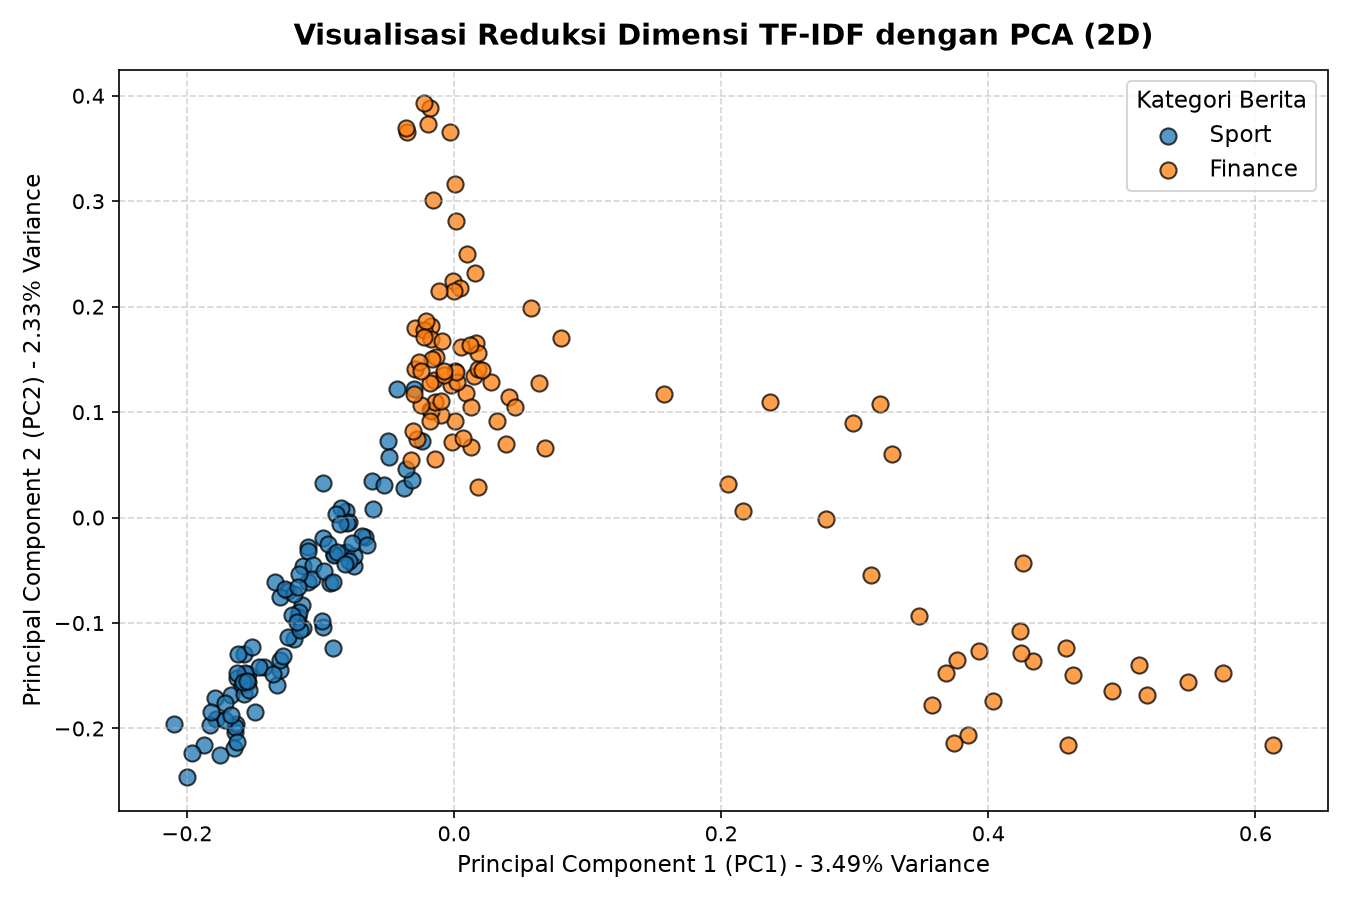

In [7]:
plt.figure(figsize=(9, 6))
labels = df_pca["Label"].unique()
colors = {"sport": "#1f77b4", "finance": "#ff7f0e"}

for label in labels:
    subset = df_pca[df_pca["Label"] == label]
    plt.scatter(
        subset["PC1"], 
        subset["PC2"], 
        label=label.capitalize(), 
        alpha=0.75, 
        edgecolors='k', 
        s=60, 
        c=colors.get(label, "gray")
    )

plt.title("Visualisasi Reduksi Dimensi TF-IDF dengan PCA (2D)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel(f"Principal Component 1 (PC1) - {pca.explained_variance_ratio_[0]*100:.2f}% Variance", fontsize=11)
plt.ylabel(f"Principal Component 2 (PC2) - {pca.explained_variance_ratio_[1]*100:.2f}% Variance", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Kategori Berita", fontsize=11, title_fontsize=11)
plt.tight_layout()
plt.show()
